## Setup

In [1]:
# GPU CHECK ────────────────────────────────────────────────────────────
%env CUDA_VISIBLE_DEVICES=0

import xgboost as xgb, os, json
import optuna, pandas as pd
import matplotlib.pyplot as plt
import shap, numpy as np
import dice_ml


from dice_ml import Dice
from scipy import sparse as sp

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, 
    average_precision_score, log_loss, 
    mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import ElasticNet, HuberRegressor, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor, Pool


env: CUDA_VISIBLE_DEVICES=0


/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


## Data Collection

In [2]:
# ── 0 · DATA ──────────────────────────────────────────────────────────
X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)
y = (y == ">50K")  # binary labels

cat = X.select_dtypes("category").columns
num = X.select_dtypes(include=["int", "float"]).columns
enc = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat),
     ("num", "passthrough",                         num)]
)

# 60% train, 20% validation, 20% test
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=0, stratify=y
)
X_va, X_te, y_va, y_te = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp
)

X_tr_enc = enc.fit_transform(X_tr)
X_va_enc = enc.transform(X_va)
X_te_enc = enc.transform(X_te)

# Ensure CSR for robust slicing/stacking
if sp.issparse(X_tr_enc): X_tr_enc = X_tr_enc.tocsr()
if sp.issparse(X_va_enc): X_va_enc = X_va_enc.tocsr()
if sp.issparse(X_te_enc): X_te_enc = X_te_enc.tocsr()

In [3]:
# Helper to simulate missing values for features
def inject_missing(X_df, num_cols, cat_cols, rate, rng):
    """Return a copy of X_df with NaNs injected at `rate` into both num & cat columns."""
    if rate <= 0:
        return X_df.copy()
    Xm = X_df.copy()
    n = len(Xm)
    # numeric
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all():  # avoid all-NaN column
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    # categorical
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all():
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

In [4]:

def objective(trial):
    # ----- XGBoost hyperparameters (widened) -----
    params = {
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "n_estimators":  trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":     trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.5, log=True),

        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 100.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 10.0),
        "lambda":           trial.suggest_float("lambda", 1e-4, 100.0, log=True),
        "alpha":            trial.suggest_float("alpha", 1e-4, 100.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),

        "tree_method": "gpu_hist",
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "predictor":  "gpu_predictor",
        "objective":  "binary:logistic",
        "eval_metric": "error",  # kept as you had; we compute F1 separately
        "verbosity": 0,
        "gpu_id": 0,
        "random_state": 0,
    }
    if params["booster"] == "dart":
        params.update(
            rate_drop      = trial.suggest_float("rate_drop", 0.0, 0.5),
            skip_drop      = trial.suggest_float("skip_drop", 0.0, 0.9),
            sample_type    = trial.suggest_categorical("sample_type", ["uniform", "weighted"]),
            normalize_type = trial.suggest_categorical("normalize_type", ["tree", "forest"]),
        )

    # ----- Soft knobs -----
    # RNG for row operations (independent of missing rate)
    rng_rows = np.random.default_rng(trial.number)

    # 1) Stratified row subsample of the TRAIN set
    sample_rows = trial.suggest_float("params_sample_rows", 0.5, 1.0)
    y_tr_np = np.asarray(y_tr, dtype=int)
    idx_pos = np.where(y_tr_np == 1)[0]
    idx_neg = np.where(y_tr_np == 0)[0]
    n_pos   = max(1, int(len(idx_pos) * sample_rows))
    n_neg   = max(1, int(len(idx_neg) * sample_rows))
    sub_pos = rng_rows.choice(idx_pos, size=n_pos, replace=False)
    sub_neg = rng_rows.choice(idx_neg, size=n_neg, replace=False)
    tr_sel  = np.concatenate([sub_pos, sub_neg])
    rng_rows.shuffle(tr_sel)
    ytr_sub = y_tr_np[tr_sel].astype(int)

    # --- SIMPLE missingness: apply ONLY on TRAIN (val/test clean) ---
    u = trial.suggest_float("params_missing_rate", 0.0, 0.10)
    _grid = np.array([0.00, 0.02, 0.05, 0.08, 0.10])
    missing_rate = float(_grid[np.argmin(np.abs(_grid - u))])
    rng_mask = np.random.default_rng((trial.number, int(round(missing_rate * 100))))
    X_tr_masked = inject_missing(X.iloc[tr_sel], num, cat, missing_rate, rng_mask)
    X_va_masked = X_va  # keep validation clean
    X_te_masked = X_te  # keep test clean

    # Preprocess: categorical impute+OHE; numeric passthrough (XGB handles NaN)
    preproc = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat),
        ("num", "passthrough", num),
    ])
    params["missing"] = np.nan  # tell XGBoost what 'missing' is

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va_masked)
    Xte_enc = preproc.transform(X_te_masked)

    if sp.issparse(Xtr_enc): Xtr_enc = Xtr_enc.tocsr()
    if sp.issparse(Xva_enc): Xva_enc = Xva_enc.tocsr()
    if sp.issparse(Xte_enc): Xte_enc = Xte_enc.tocsr()

    # 2) Simple re-sampling on subsample
    resampling_strategy = trial.suggest_categorical("params_resampling", ["none", "undersample", "oversample"])
    # Avoid double-compensation for imbalance
    if resampling_strategy != "none":
        params["scale_pos_weight"] = 1.0
    else:
        params["scale_pos_weight"] = trial.suggest_float("params_scale_pos_weight", 0.5, 5.0, log=True)

    ysub = np.asarray(ytr_sub, dtype=int)
    pos_idx = np.where(ysub == 1)[0]
    neg_idx = np.where(ysub == 0)[0]
    n_pos_s, n_neg_s = len(pos_idx), len(neg_idx)

    def _stack_rows(XA, XB):
        if sp.issparse(XA) or sp.issparse(XB):
            XA = XA.tocsr() if sp.issparse(XA) else sp.csr_matrix(XA)
            XB = XB.tocsr() if sp.issparse(XB) else sp.csr_matrix(XB)
            return sp.vstack([XA, XB], format="csr")
        else:
            return np.vstack([XA, XB])

    if resampling_strategy == "undersample" and n_pos_s > 0 and n_neg_s > 0:
        n_min = min(n_pos_s, n_neg_s)
        pos_keep = rng_rows.choice(pos_idx, size=n_min, replace=False)
        neg_keep = rng_rows.choice(neg_idx, size=n_min, replace=False)
        keep = np.concatenate([pos_keep, neg_keep])
        Xtr_enc = Xtr_enc[keep]
        ytr_sub = ytr_sub[keep].astype(int)
        ysub    = ytr_sub
        pos_idx = np.where(ysub == 1)[0]
        neg_idx = np.where(ysub == 0)[0]
    elif resampling_strategy == "oversample" and n_pos_s > 0 and n_neg_s > 0:
        n_max = max(n_pos_s, n_neg_s)
        pos_add = rng_rows.choice(pos_idx, size=n_max - n_pos_s, replace=True) if n_pos_s < n_max else np.array([], dtype=int)
        neg_add = rng_rows.choice(neg_idx, size=n_max - n_neg_s, replace=True) if n_neg_s < n_max else np.array([], dtype=int)
        add_idx = np.concatenate([pos_add, neg_add])
        if add_idx.size > 0:
            Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add_idx])
            ytr_sub = np.concatenate([ytr_sub, ytr_sub[add_idx]]).astype(int)
            ysub    = ytr_sub
            pos_idx = np.where(ysub == 1)[0]
            neg_idx = np.where(ysub == 0)[0]

    # 3) Random feature subset applied consistently
    feature_fraction = trial.suggest_float("params_feature_fraction", 0.5, 1.0)
    n_features = Xtr_enc.shape[1]
    k_features = max(1, int(n_features * feature_fraction))
    feat_idx   = np.sort(rng_rows.choice(np.arange(n_features), size=k_features, replace=False))

    def _col_slice(M, cols):
        return M[:, cols]

    Xtr_sub = _col_slice(Xtr_enc, feat_idx)
    Xva_sub = _col_slice(Xva_enc, feat_idx)
    Xte_sub = _col_slice(Xte_enc, feat_idx)

    # ── Semi-supervised labels (−1 == unlabeled) on TRAIN ONLY ──────────
    labeled_ratio = trial.suggest_float("params_labeled_ratio", 0.05, 0.95)
    if (len(pos_idx) > 0 and len(neg_idx) > 0) and (labeled_ratio < 1.0):
        keep_pos = max(1, int(round(len(pos_idx) * labeled_ratio)))
        keep_neg = max(1, int(round(len(neg_idx) * labeled_ratio)))
        keep_pos = min(keep_pos, len(pos_idx))
        keep_neg = min(keep_neg, len(neg_idx))

        labeled_keep = np.concatenate([
            rng_rows.choice(pos_idx, size=keep_pos, replace=False),
            rng_rows.choice(neg_idx, size=keep_neg, replace=False)
        ])

        y_semi = np.full(ytr_sub.shape, -1, dtype=int)  # unlabeled by default
        y_semi[labeled_keep] = ytr_sub[labeled_keep]
        n_labeled   = int((y_semi != -1).sum())
        n_unlabeled = int((y_semi == -1).sum())

        if n_unlabeled == 0:
            clf = xgb.XGBClassifier(**params)
            clf.fit(Xtr_sub, ytr_sub)
            n_labeled, n_unlabeled = int(len(ytr_sub)), 0
        else:
            from sklearn.semi_supervised import SelfTrainingClassifier
            st = SelfTrainingClassifier(
                estimator=xgb.XGBClassifier(**params),
                threshold=trial.suggest_float("params_selftrain_threshold", 0.6, 0.95),
                max_iter=trial.suggest_int("params_selftrain_max_iter", 5, 12),
                verbose=False
            )
            st.fit(Xtr_sub, y_semi)
            clf = st
    else:
        clf = xgb.XGBClassifier(**params)
        clf.fit(Xtr_sub, ytr_sub)
        n_labeled   = int(len(ytr_sub))
        n_unlabeled = 0

    # ── Evaluate (compute best threshold on VAL, apply to TEST) ─────────
    y_va_int = np.asarray(y_va, dtype=int)
    y_te_int = np.asarray(y_te, dtype=int)

    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_va_int, proba_va)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = f1s.argmax()
    best_thr = 0.5 if best_idx >= len(thr) else float(thr[best_idx])

    yhat_va  = (proba_va >= best_thr).astype(int)
    f1_val   = f1_score(y_va_int, yhat_va, zero_division=0)

    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_te  = (proba_te >= best_thr).astype(int)

    # ── Log metrics (val + test) ───────────────────────────────────────
    trial.set_user_attr("f1_val", f1_val)
    trial.set_user_attr("f1_test", f1_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("acc_val",  accuracy_score(y_va_int, yhat_va))
    trial.set_user_attr("acc_test", accuracy_score(y_te_int, yhat_te))
    trial.set_user_attr("prec_val", precision_score(y_va_int, yhat_va, zero_division=0))
    trial.set_user_attr("prec_test", precision_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("rec_val",  recall_score(y_va_int, yhat_va, zero_division=0))
    trial.set_user_attr("rec_test", recall_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("roc_auc_val", roc_auc_score(y_va_int, proba_va))
    trial.set_user_attr("roc_auc_test", roc_auc_score(y_te_int, proba_te))
    trial.set_user_attr("pr_auc_val", average_precision_score(y_va_int, proba_va))
    trial.set_user_attr("pr_auc_test", average_precision_score(y_te_int, proba_te))

    # log applied soft knobs
    trial.set_user_attr("best_threshold", best_thr)
    trial.set_user_attr("sample_rows", sample_rows)
    trial.set_user_attr("resampling_strategy", resampling_strategy)
    trial.set_user_attr("feature_fraction", feature_fraction)
    trial.set_user_attr("missing_rate", missing_rate)
    trial.set_user_attr("labeled_ratio", float(labeled_ratio))
    trial.set_user_attr("n_labeled", n_labeled)
    trial.set_user_attr("n_unlabeled", n_unlabeled)

    return f1_val

In [ ]:
TARGET_TRIALS = 1000

# Let ~10–15% be pure random, then switch to TPE guidance
sampler = optuna.samplers.TPESampler(
    n_startup_trials=1000,
    n_ei_candidates=64,
    consider_prior=True,
    multivariate=True,
    group=True,
    seed=0,
)

study = optuna.create_study(
    direction="maximize",
    study_name="adult_xgb_tpe_with_soft_params",
    storage="sqlite:///adult_xgb_with_soft_params.db",
    load_if_exists=True,
    sampler=sampler,
)

already_done = len(study.trials)
remaining   = max(TARGET_TRIALS - already_done, 0)

if remaining:
    print(f"Running {remaining} additional trials (have {already_done}, need {TARGET_TRIALS})")
    study.optimize(objective, n_trials=remaining, gc_after_trial=True)
else:
    print(f"Target of {TARGET_TRIALS} trials already reached – nothing to do")

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-10-08 09:56:17,131] Using an existing study with name 'adult_xgb_tpe_with_soft_params_v2' instead of creating a new one.


Target of 100 trials already reached – nothing to do
Best F1: 0.5890388681086356
Best params: {'booster': 'gbtree', 'n_estimators': 900, 'max_depth': 12, 'learning_rate': 0.0014751085629446875, 'min_child_weight': 6.363596390862163, 'gamma': 6.50788270377181, 'lambda': 0.021238876969796917, 'alpha': 3.43340875561599, 'subsample': 0.23981292711117033, 'colsample_bytree': 0.8122809965531889, 'grow_policy': 'lossguide', 'max_delta_step': 9, 'params_sample_rows': 0.814331414302032, 'params_missing_rate': 0.045384303790691034, 'params_resampling': 'none', 'params_scale_pos_weight': 1.7147736418093222, 'params_feature_fraction': 0.7652542668573933, 'params_labeled_ratio': 0.12090560583236738, 'params_selftrain_threshold': 0.8446710085913007, 'params_selftrain_max_iter': 9}


In [ ]:
# --- Save trials dataframe to CSV ---
df = study.trials_dataframe()
CSV = "adult_xgb_trials_with_soft_params.csv"
df.to_csv(CSV, index=False)
print(f"Saved {len(df)} trials to {CSV}")

Saved 7075 trials to adult_xgb_trials_with_soft_params_v3.csv


## Exploring collected data

In [ ]:
# ========== STEP 1 · Explore the Optuna trials dataset ==========

# --- 1.1 Load ---
v1 = pd.read_csv("adult_xgb_trials_with_soft_params.csv", index_col=0)
v3 = pd.read_csv("adult_xgb_trials_with_soft_params_v3.csv", index_col=0)
print(f"Rows: {len(v1) :,} {len(v3) :,}  |  Columns: {v1.shape[1], v3.shape[1]}")
display(v1.iloc[:3, :42].T)
display(v3.iloc[:3, :51].T)

Rows: 4,013 7,075  |  Columns: (42, 51)


number,0,1,2
value,0.36609,0.61967,NaN
datetime_start,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.831814
datetime_complete,2025-09-23 10:49:52.201781,2025-09-23 10:49:52.728582,2025-09-23 10:50:07.822280
duration,0 days 00:00:34.507151,0 days 00:00:00.425862,0 days 00:00:14.990466
params_alpha,60.530821,0.507941,0.829182
params_booster,dart,gbtree,dart
params_colsample_bytree,0.83338,0.693547,0.573049
params_gamma,4.375872,5.684339,2.088768
params_grow_policy,lossguide,depthwise,depthwise
params_lambda,22.420124,0.00013,0.000929


number,0,1,2
value,0.386121,0.0,0.0
datetime_start,2025-10-03 09:24:32.727473,2025-10-03 09:26:20.428473,2025-10-03 09:26:21.400575
datetime_complete,2025-10-03 09:26:20.247780,2025-10-03 09:26:21.240707,2025-10-03 09:26:22.540409
duration,0 days 00:01:47.520307,0 days 00:00:00.812234,0 days 00:00:01.139834
params_alpha,60.530821,1.232883,0.001512
params_booster,dart,gbtree,gbtree
params_colsample_bytree,0.83338,0.549626,0.856795
params_gamma,4.375872,6.16934,6.563296
params_grow_policy,lossguide,depthwise,lossguide
params_lambda,22.420124,45.971478,0.000675


In [9]:
# Merge and tag sources
v1_ = v1.copy(); v1_["source"] = "v1"
v3_ = v3.copy(); v3_["source"] = "v3"
df = pd.concat([v1_, v3_], ignore_index=True, sort=False)

# Columns absent in v1 originally
V3_ONLY = [
    "params_params_labeled_ratio",
    "params_params_missing_rate",
    "params_params_selftrain_max_iter",
    "params_params_selftrain_threshold",
    "user_attrs_best_threshold",   # will be dropped
    "user_attrs_labeled_ratio",
    "user_attrs_missing_rate",
    "user_attrs_n_labeled",
    "user_attrs_n_unlabeled",
]

# Default fill values for v1 rows
fills_numeric = {
    "params_params_labeled_ratio": 1.0,
    "params_params_missing_rate": 0.0,
    "params_params_selftrain_max_iter": 0,
    "params_params_selftrain_threshold": 1.0,
    "user_attrs_labeled_ratio": 1.0,
    "user_attrs_missing_rate": 0.0,
}

SENTINEL = "<NOT_COLLECTED_IN_V1>"
mask_v1 = df["source"].eq("v1")

for col, val in fills_numeric.items():
    if col not in df.columns:
        df[col] = np.nan
    miss = df[col].isna() | (df[col].astype(str) == SENTINEL)
    df.loc[mask_v1 & miss, col] = val
    df[col] = pd.to_numeric(df[col])

# Drop best_threshold completely
df = df.drop(columns=["user_attrs_n_labeled", "user_attrs_n_unlabeled", "user_attrs_best_threshold"])

In [ ]:
# --- 1.3 Quick preview ---
# A) Wide preview: first 5 rows with ALL columns (no truncation)
display(df.iloc[:5])

display(df.iloc[:10, :51].T)

# Optional: show *all* column names as a numbered list
for i, c in enumerate(df.columns, 1):
    print(f"{i:>3}. {c}")

,value,datetime_start,datetime_complete,duration,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,...,user_attrs_roc_auc_val,user_attrs_sample_rows,state,source,params_params_labeled_ratio,params_params_missing_rate,params_params_selftrain_max_iter,params_params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate
0,0.366090,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.201781,0 days 00:00:34.507151,60.530821,dart,0.833380,4.375872,lossguide,22.420124,...,0.799956,0.730740,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0
1,0.619670,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.728582,0 days 00:00:00.425862,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,...,0.901404,0.530113,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0
2,NaN,2025-09-23 10:49:52.831814,2025-09-23 10:50:07.822280,0 days 00:00:14.990466,0.829182,dart,0.573049,2.088768,depthwise,0.000929,...,NaN,NaN,FAIL,v1,1.0,0.0,0.0,1.0,1.0,0.0
3,0.642549,2025-09-23 10:50:38.666877,2025-09-23 10:51:13.394300,0 days 00:00:34.727423,60.530821,dart,0.833380,4.375872,lossguide,22.420124,...,0.892885,0.730740,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0
4,0.594286,2025-09-23 10:51:13.518457,2025-09-23 10:51:13.940724,0 days 00:00:00.422267,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,...,0.874227,0.530113,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0


,0,1,2,3,4,5,6,7,8,9
value,0.36609,0.61967,NaN,0.642549,0.594286,0.7028,0.426952,0.654116,0.0,0.655462
datetime_start,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.831814,2025-09-23 10:50:38.666877,2025-09-23 10:51:13.518457,2025-09-23 10:51:14.056072,2025-09-23 10:51:44.256588,2025-09-23 10:51:49.264659,2025-09-23 10:52:00.162444,2025-09-23 10:52:15.976721
datetime_complete,2025-09-23 10:49:52.201781,2025-09-23 10:49:52.728582,2025-09-23 10:50:07.822280,2025-09-23 10:51:13.394300,2025-09-23 10:51:13.940724,2025-09-23 10:51:44.136658,2025-09-23 10:51:49.148416,2025-09-23 10:52:00.044213,2025-09-23 10:52:15.856974,2025-09-23 10:52:16.396982
duration,0 days 00:00:34.507151,0 days 00:00:00.425862,0 days 00:00:14.990466,0 days 00:00:34.727423,0 days 00:00:00.422267,0 days 00:00:30.080586,0 days 00:00:04.891828,0 days 00:00:10.779554,0 days 00:00:15.694530,0 days 00:00:00.420261
params_alpha,60.530821,0.507941,0.829182,60.530821,0.507941,0.829182,1.428344,0.048167,0.830242,71.306485
params_booster,dart,gbtree,dart,dart,gbtree,dart,dart,dart,dart,gbtree
params_colsample_bytree,0.83338,0.693547,0.573049,0.83338,0.693547,0.573049,0.412312,0.759583,0.545135,0.209371
params_gamma,4.375872,5.684339,2.088768,4.375872,5.684339,2.088768,4.14263,2.230816,5.908728,7.220556
params_grow_policy,lossguide,depthwise,depthwise,lossguide,depthwise,depthwise,depthwise,lossguide,depthwise,lossguide
params_lambda,22.420124,0.00013,0.000929,22.420124,0.00013,0.000929,0.000243,52.05879,0.279223,15.786794


  1. value
  2. datetime_start
  3. datetime_complete
  4. duration
  5. params_alpha
  6. params_booster
  7. params_colsample_bytree
  8. params_gamma
  9. params_grow_policy
 10. params_lambda
 11. params_learning_rate
 12. params_max_delta_step
 13. params_max_depth
 14. params_min_child_weight
 15. params_n_estimators
 16. params_normalize_type
 17. params_params_decision_threshold
 18. params_params_feature_fraction
 19. params_params_resampling
 20. params_params_sample_rows
 21. params_params_scale_pos_weight
 22. params_rate_drop
 23. params_sample_type
 24. params_skip_drop
 25. params_subsample
 26. user_attrs_acc_test
 27. user_attrs_acc_val
 28. user_attrs_decision_threshold
 29. user_attrs_f1_test
 30. user_attrs_f1_val
 31. user_attrs_feature_fraction
 32. user_attrs_pr_auc_test
 33. user_attrs_pr_auc_val
 34. user_attrs_prec_test
 35. user_attrs_prec_val
 36. user_attrs_rec_test
 37. user_attrs_rec_val
 38. user_attrs_resampling_strategy
 39. user_attrs_roc_auc_test
 40

In [ ]:
# --- 1.2 Column groups ---
col_groups = {
    "params":        [c for c in df.columns if c.startswith("params_")],
    "user_attrs":    [c for c in df.columns if c.startswith("user_attrs_")],
    "optuna_core":   [c for c in ["number", "value", "state", "datetime_start", "datetime_complete", "duration"] if c in df.columns],
    "other":         []
}
used = set(sum(col_groups.values(), []))
col_groups["other"] = [c for c in df.columns if c not in used]

for k in ["optuna_core", "params", "user_attrs", "other"]:
    if col_groups[k]:
        print(f"\n[{k}] ({len(col_groups[k])}):")
        preview = ", ".join(col_groups[k][:12])
        print(preview + (" ..." if len(col_groups[k]) > 12 else ""))


[optuna_core] (5):
value, state, datetime_start, datetime_complete, duration

[params] (25):
params_alpha, params_booster, params_colsample_bytree, params_gamma, params_grow_policy, params_lambda, params_learning_rate, params_max_delta_step, params_max_depth, params_min_child_weight, params_n_estimators, params_normalize_type ...

[user_attrs] (18):
user_attrs_acc_test, user_attrs_acc_val, user_attrs_decision_threshold, user_attrs_f1_test, user_attrs_f1_val, user_attrs_feature_fraction, user_attrs_pr_auc_test, user_attrs_pr_auc_val, user_attrs_prec_test, user_attrs_prec_val, user_attrs_rec_test, user_attrs_rec_val ...

[other] (1):
source


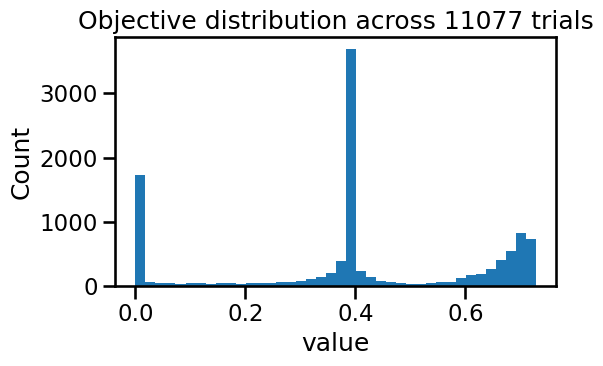

In [ ]:
# --- 1.5 Objective distribution (value = F1_val) ---
if "value" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["value"].dropna(), bins=40)
    plt.xlabel("value")
    plt.ylabel("Count")
    plt.title(f"Objective distribution across {df['value'].notna().sum()} trials")
    plt.tight_layout()
    plt.show()

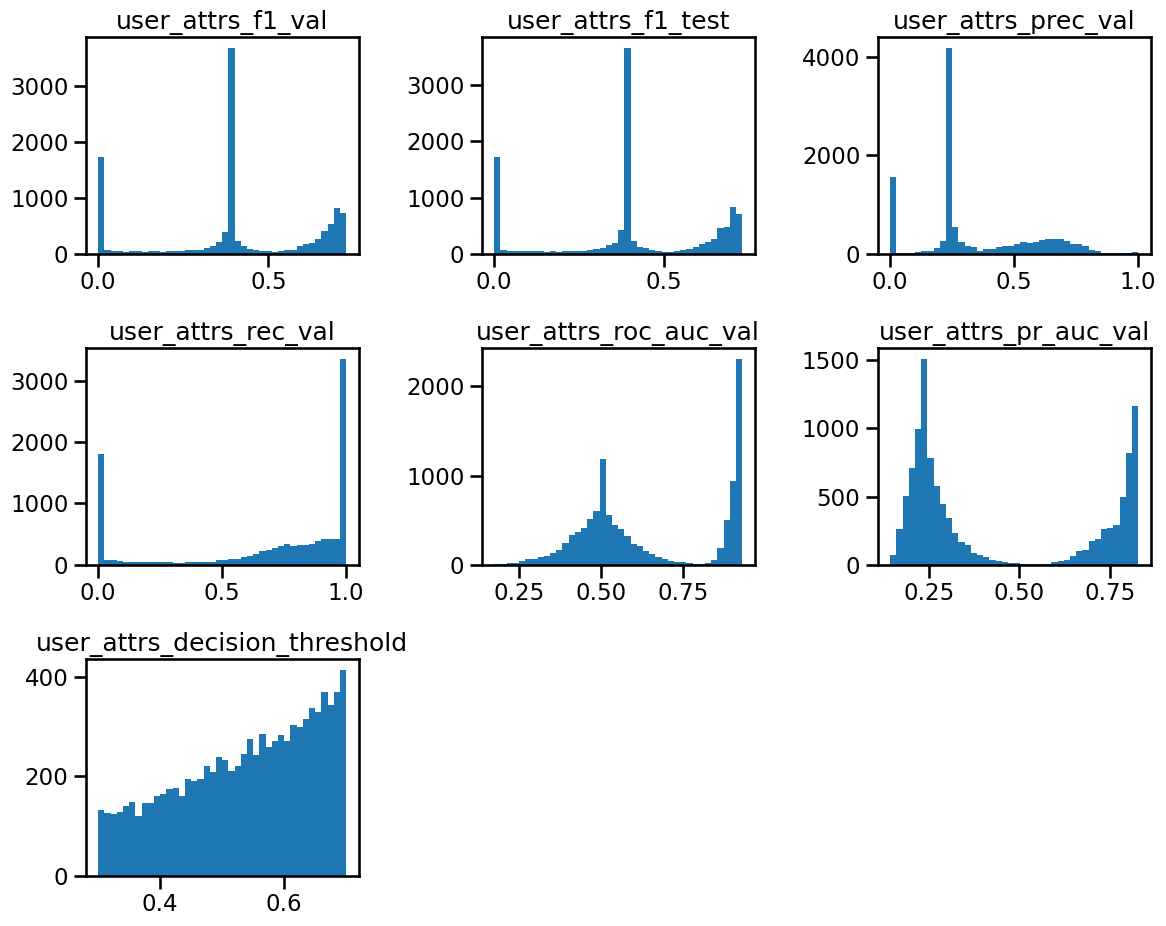

In [13]:
# --- 1.6 Key metric histograms ---
key_metrics = [m for m in [
    "user_attrs_f1_val", "user_attrs_f1_test",
    "user_attrs_prec_val", "user_attrs_rec_val",
    "user_attrs_roc_auc_val", "user_attrs_pr_auc_val",
    "user_attrs_decision_threshold"
] if m in df.columns]

if key_metrics:
    n = len(key_metrics)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 3.2*nrows))
    for i, m in enumerate(key_metrics, 1):
        plt.subplot(nrows, ncols, i)
        plt.hist(pd.to_numeric(df[m], errors="coerce").dropna(), bins=40)
        plt.title(m)
        plt.tight_layout()
    plt.show()

In [14]:
# --- 1.7 Categorical knobs summary (value counts) ---
for col in ["params_booster", "params_grow_policy", "params_params_resampling"]:
    if col in df.columns:
        print(f"\nValue counts — {col}:")
        print(df[col].value_counts(dropna=False))


Value counts — params_booster:
params_booster
dart      5686
gbtree    5402
Name: count, dtype: int64

Value counts — params_grow_policy:
params_grow_policy
lossguide    5671
depthwise    5417
Name: count, dtype: int64

Value counts — params_params_resampling:
params_params_resampling
undersample    4109
none           3972
oversample     3005
NaN               2
Name: count, dtype: int64


In [15]:
# --- 1.9 Best & worst trials by objective ---
if "value" in df.columns and df["value"].notna().any():
    best_idx = df["value"].idxmax()
    worst_idx = df["value"].idxmin()
    best, worst = df.loc[best_idx], df.loc[worst_idx]
    print("\n=== BEST trial ===")
    display(best.filter(like="param_").to_frame().T)
    print(f"value (objective): {best['value']:.4f}")
    print("\n=== WORST trial ===")
    display(worst.filter(like="param_").to_frame().T)
    print(f"value (objective): {worst['value']:.4f}")


=== BEST trial ===


""
2893


value (objective): 0.7285

=== WORST trial ===


""
8


value (objective): 0.0000


## Cleaning dataset

In [16]:
# keep only successful trials
df_clean = df[df["state"] != "FAIL"].copy()

print(f"Original rows: {len(df)}")
print(f"After removing FAIL rows: {len(df_clean)}")


Original rows: 11088
After removing FAIL rows: 11077


In [ ]:
drop_cols = [
    "number",
    "params_params_decision_threshold",
    "params_params_feature_fraction",
    "params_params_sample_rows",
    "params_params_resampling",
    "datetime_start",
    "datetime_complete",
    "duration",
    "state",
    "source"
]

df_clean = df_clean.drop(columns=drop_cols, errors="ignore")

NameError: name 'df_clean' is not defined

## Feature engineering (soft params)

### 1) Risk preference

In [18]:
# Proxy for risk preference
thr = pd.Series(df_clean.get("user_attrs_decision_threshold", np.nan)).fillna(0.5)
spw = pd.Series(df_clean.get("params_params_scale_pos_weight", np.nan)).fillna(1.0)
res = pd.Series(df_clean.get("user_attrs_resampling_strategy", np.nan)).fillna("none").astype(str)

risk_score = (- (thr - 0.5)) + np.log(spw) + res.map({"oversample": 1, "undersample": 0.5}).fillna(0)

def label_risk(s, tol=0.2):
    if pd.isna(s): 
        return np.nan
    if abs(s) < tol:
        return "balanced"
    return "recall_pref" if s > 0 else "precision_pref"

df_clean["soft_risk_preference"] = risk_score.map(label_risk)

### 2) Decision speed (model complexity)

In [19]:
# proxy for complexity: depth × n_estimators
comp = df_clean["params_max_depth"] * df_clean["params_n_estimators"]

# thresholds: tertiles (low/med/high)
q1, q2 = comp.quantile([0.33, 0.66])

def label_speed(x):
    if pd.isna(x): 
        return np.nan
    if x < q1: 
        return "fast"
    if x < q2: 
        return "balanced"
    return "slow"

df_clean["soft_decision_speed"] = comp.map(label_speed)

### 3) Dataset size

In [ ]:
# total training rows from 60/20/20 split
N_train = len(X_tr)   # reuse X_tr from split above

# fraction column (present in either user_attrs or params)
frac = df_clean.get("user_attrs_sample_rows")

# numeric: number of rows actually used in training
df_clean["soft_train_rows"] = (frac * N_train).round().astype("Int64")


In [ ]:
# --- 1.3 Quick preview ---
# A) Wide preview: first 5 rows with ALL columns (no truncation)
display(df_clean.iloc[:5])

# B) Tall/rotated preview: all columns transposed (easier to scan names/values)
first_k = 48
display(df_clean.iloc[:5, :first_k].T)

# Optional: show *all* column names as a numbered list (easy to scan/search)
for i, c in enumerate(df_clean.columns, 1):
    print(f"{i:>3}. {c}")

,value,datetime_start,datetime_complete,duration,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,...,source,params_params_labeled_ratio,params_params_missing_rate,params_params_selftrain_max_iter,params_params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate,soft_risk_preference,soft_decision_speed,soft_train_rows
0,0.366090,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.201781,0 days 00:00:34.507151,60.530821,dart,0.833380,4.375872,lossguide,22.420124,...,v1,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,slow,21414
1,0.619670,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.728582,0 days 00:00:00.425862,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,...,v1,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,balanced,15535
3,0.642549,2025-09-23 10:50:38.666877,2025-09-23 10:51:13.394300,0 days 00:00:34.727423,60.530821,dart,0.833380,4.375872,lossguide,22.420124,...,v1,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,slow,21414
4,0.594286,2025-09-23 10:51:13.518457,2025-09-23 10:51:13.940724,0 days 00:00:00.422267,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,...,v1,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,balanced,15535
5,0.702800,2025-09-23 10:51:14.056072,2025-09-23 10:51:44.136658,0 days 00:00:30.080586,0.829182,dart,0.573049,2.088768,depthwise,0.000929,...,v1,1.0,0.0,0.0,1.0,1.0,0.0,balanced,slow,28960


,0,1,3,4,5
value,0.36609,0.61967,0.642549,0.594286,0.7028
datetime_start,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.302720,2025-09-23 10:50:38.666877,2025-09-23 10:51:13.518457,2025-09-23 10:51:14.056072
datetime_complete,2025-09-23 10:49:52.201781,2025-09-23 10:49:52.728582,2025-09-23 10:51:13.394300,2025-09-23 10:51:13.940724,2025-09-23 10:51:44.136658
duration,0 days 00:00:34.507151,0 days 00:00:00.425862,0 days 00:00:34.727423,0 days 00:00:00.422267,0 days 00:00:30.080586
params_alpha,60.530821,0.507941,60.530821,0.507941,0.829182
params_booster,dart,gbtree,dart,gbtree,dart
params_colsample_bytree,0.83338,0.693547,0.83338,0.693547,0.573049
params_gamma,4.375872,5.684339,4.375872,5.684339,2.088768
params_grow_policy,lossguide,depthwise,lossguide,depthwise,depthwise
params_lambda,22.420124,0.00013,22.420124,0.00013,0.000929


  1. value
  2. datetime_start
  3. datetime_complete
  4. duration
  5. params_alpha
  6. params_booster
  7. params_colsample_bytree
  8. params_gamma
  9. params_grow_policy
 10. params_lambda
 11. params_learning_rate
 12. params_max_delta_step
 13. params_max_depth
 14. params_min_child_weight
 15. params_n_estimators
 16. params_normalize_type
 17. params_params_scale_pos_weight
 18. params_rate_drop
 19. params_sample_type
 20. params_skip_drop
 21. params_subsample
 22. user_attrs_acc_test
 23. user_attrs_acc_val
 24. user_attrs_decision_threshold
 25. user_attrs_f1_test
 26. user_attrs_f1_val
 27. user_attrs_feature_fraction
 28. user_attrs_pr_auc_test
 29. user_attrs_pr_auc_val
 30. user_attrs_prec_test
 31. user_attrs_prec_val
 32. user_attrs_rec_test
 33. user_attrs_rec_val
 34. user_attrs_resampling_strategy
 35. user_attrs_roc_auc_test
 36. user_attrs_roc_auc_val
 37. user_attrs_sample_rows
 38. state
 39. source
 40. params_params_labeled_ratio
 41. params_params_missing

In [36]:
csv_path = "ready_for_surrogates.csv"
df_clean.to_csv(csv_path, index=False)
print(f"\nSaved clean dataset to: {csv_path}  | shape={df_clean.shape}")


Saved clean dataset to: ready_for_surrogates.csv  | shape=(11077, 48)


## Training surrogate models

In [3]:
# --- Load ---
df_sur = pd.read_csv("data/ready_for_surrogates.csv", low_memory=False)
print(f"Loaded dataset from CSV  | shape={df_sur.shape}")

# --- Target ---
y_sur = df_sur["value"].rename("f1")

# --- features (normalize params_params_* -> params_*) ---
desired_features_raw = [
    "params_alpha","params_booster","params_colsample_bytree","params_gamma",
    "params_grow_policy","params_lambda","params_learning_rate","params_max_delta_step",
    "params_max_depth","params_min_child_weight","params_n_estimators","params_normalize_type",
    "params_params_scale_pos_weight","params_rate_drop","params_sample_type","params_skip_drop",
    "params_subsample","user_attrs_decision_threshold","user_attrs_feature_fraction",
    "user_attrs_resampling_strategy","user_attrs_sample_rows","params_params_labeled_ratio",
    "params_params_missing_rate","params_params_selftrain_max_iter","params_params_selftrain_threshold",
    "user_attrs_labeled_ratio","user_attrs_missing_rate","soft_risk_preference",
    "soft_decision_speed","soft_train_rows",
]
desired_features = [c.replace("params_params_", "params_") for c in desired_features_raw]
df_sur = df_sur.rename(columns=lambda c: c.replace("params_params_", "params_"))

present = [c for c in desired_features if c in df_sur.columns]
missing = [c for c in desired_features if c not in df_sur.columns]
if missing:
    print("WARNING: missing requested features (skipped):", missing)

X_sur = df_sur[present].copy()

# --- DART conditionals (only if booster column exists) ---
if "params_booster" in X_sur.columns:
    dart_float = [c for c in ["params_rate_drop","params_skip_drop"] if c in X_sur.columns]
    dart_cat   = [c for c in ["params_sample_type","params_normalize_type"] if c in X_sur.columns]
    mask_not_dart = X_sur["params_booster"].astype(str).ne("dart")
    for c in dart_float: X_sur.loc[mask_not_dart, c] = 0.0
    for c in dart_cat:   X_sur.loc[mask_not_dart, c] = "NA"

# --- Treat specific NaNs as "use default" ------------------------------------
# Defaults: scale_pos_weight=1.0, decision_threshold=0.5
if "params_scale_pos_weight" in X_sur.columns:
    X_sur["params_scale_pos_weight"] = pd.to_numeric(X_sur["params_scale_pos_weight"], errors="coerce").fillna(1.0)
if "user_attrs_decision_threshold" in X_sur.columns:
    X_sur["user_attrs_decision_threshold"] = pd.to_numeric(X_sur["user_attrs_decision_threshold"], errors="coerce").fillna(0.5)

# --- Dtypes: make obvious categoricals strings (helps OHE) -------------------
for c in ["params_booster","params_grow_policy","params_sample_type","params_normalize_type",
          "user_attrs_resampling_strategy","soft_risk_preference","soft_decision_speed"]:
    if c in X_sur.columns:
        X_sur[c] = X_sur[c].astype("string")

# --- Columns by type ---------------------------------------------------------
cat_cols = X_sur.select_dtypes(include=["object","category","string"]).columns.tolist()
num_cols = X_sur.columns.difference(cat_cols).tolist()

# --- Preprocessor: cats -> OHE (with NA token), nums -> median impute --------
preproc = ColumnTransformer([
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

# --- Quick sanity prints ------------------------------------------------------
print("\nSelected features:", len(X_sur.columns))
print("Categorical:", len(cat_cols), "| Numeric:", len(num_cols))
print("\nmissing counts:")
print(X_sur.isna().sum().sort_values(ascending=False).head())

# --- Train / validation split -------------------------------------------------
X_tr_sur, X_va_sur, y_tr_sur, y_va_sur = train_test_split(
    X_sur, y_sur, test_size=0.2, random_state=0
)

Loaded dataset from CSV  | shape=(11077, 43)

Selected features: 30
Categorical: 7 | Numeric: 23

missing counts:
params_alpha               0
params_booster             0
soft_decision_speed        0
soft_risk_preference       0
user_attrs_missing_rate    0
dtype: int64


In [4]:
# -----------------------------------------------------------------------------
# 1) Helpers
# -----------------------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_ohe_dense():
    """Version-safe dense OHE (sklearn>=1.2 uses sparse_output)."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def evaluate_pipe(name, pipe, X_tr=X_tr_sur, y_tr=y_tr_sur, X_va=X_va_sur, y_va=y_va_sur):
    pipe.fit(X_tr, y_tr)
    yhat = pipe.predict(X_va)
    res = {
        "name": name,
        "rmse": rmse(y_va, yhat),
        "mae":  mean_absolute_error(y_va, yhat),
        "r2":   r2_score(y_va, yhat),
        "predict_fn": lambda X: pipe.predict(X),
    }
    print(f"[{name}] RMSE={res['rmse']:.4f} | MAE={res['mae']:.4f} | R²={res['r2']:.4f}")
    return res


In [5]:
# -----------------------------------------------------------------------------
# 2) Shared preprocessors (define ONCE)
# -----------------------------------------------------------------------------
# NaN-safe trees (sklearn trees don’t accept NaNs in numerics)
preproc_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),    # OHE handles NaN category
    ("num", SimpleImputer(strategy="median"),        num_cols),   # impute numeric NaNs
])

# Dense-required models (HGBDT, KNN, SVR)
preproc_dense = ColumnTransformer([
    ("cat", make_ohe_dense(), cat_cols),
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
])

# Linear models (impute + scale)
cat_lin = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
num_lin = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler()),
])
lin_preproc = ColumnTransformer([
    ("cat", cat_lin, cat_cols),
    ("num", num_lin, num_cols),
])

In [6]:
# -----------------------------------------------------------------------------
# 3) Models dictionary (no duplication)
# -----------------------------------------------------------------------------
models = {
    # Boosters (use your sparse OHE preproc)
    "LightGBM": Pipeline([
        ("pre", preproc),
        ("lgb", LGBMRegressor(
            n_estimators=1500, learning_rate=0.03,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, random_state=0
        ))
    ]),
    "XGBoost": Pipeline([
        ("pre", preproc),
        ("xgb", XGBRegressor(
            n_estimators=1500, learning_rate=0.03, max_depth=8,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, reg_alpha=0.0,
            tree_method="hist", random_state=0, n_jobs=-1
        ))
    ]),

    # Sklearn tree family (NaN-safe preproc_tree)
    "ExtraTrees": Pipeline([
        ("pre", preproc_tree),
        ("et", ExtraTreesRegressor(
            n_estimators=1200, max_features=None, min_samples_leaf=1,
            random_state=0, n_jobs=-1
        ))
    ]),
    "RandomForest": Pipeline([
        ("pre", preproc_tree),
        ("rf", RandomForestRegressor(
            n_estimators=800, max_depth=None, min_samples_leaf=1,
            random_state=0, n_jobs=-1
        ))
    ]),
    "GBRegressor": Pipeline([
        ("pre", preproc_tree),
        ("gbr", GradientBoostingRegressor(
            n_estimators=800, learning_rate=0.05, max_depth=3, subsample=0.8,
            random_state=0
        ))
    ]),
    "AdaBoost": Pipeline([
        ("pre", preproc_tree),
        ("ada", AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=6, random_state=0),
            n_estimators=400, learning_rate=0.05, random_state=0
        ))
    ]),
    "DecisionTree": Pipeline([
        ("pre", preproc_tree),
        ("dt", DecisionTreeRegressor(max_depth=None, random_state=0))
    ]),

    # Dense-required
    "HistGBDT": Pipeline([
        ("pre", preproc_dense),
        ("hgb", HistGradientBoostingRegressor(
            max_depth=None, max_bins=255, learning_rate=0.06,
            min_samples_leaf=20, l2_regularization=1.0,
            early_stopping=True, random_state=0
        ))
    ]),
    "KNN": Pipeline([
        ("pre", Pipeline([("ct", preproc_dense), ("sc", StandardScaler(with_mean=False))])),
        ("knn", KNeighborsRegressor(n_neighbors=15, weights="distance", p=2, n_jobs=-1))
    ]),
    "SVR": Pipeline([
        ("pre", Pipeline([("ct", preproc_dense), ("sc", StandardScaler(with_mean=False))])),
        ("svr", SVR(C=3.0, epsilon=0.02, gamma="scale"))
    ]),

    # Linear baselines
    "ElasticNet": Pipeline([
        ("pre", lin_preproc),
        ("lr",  ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=0, max_iter=10000))
    ]),
    "HuberReg": Pipeline([
        ("pre", lin_preproc),
        ("huber", HuberRegressor(alpha=1e-4, epsilon=1.35, max_iter=2000))
    ]),
    "BayesianRidge": Pipeline([
        ("pre", lin_preproc),
        ("br", BayesianRidge())
    ]),
}

In [7]:
# -----------------------------------------------------------------------------
# 4) CatBoost (native categoricals) — evaluated separately
# -----------------------------------------------------------------------------
results = []
cat_idx = [X_sur.columns.get_loc(c) for c in cat_cols]
cb_params = dict(
    depth=8, learning_rate=0.05, l2_leaf_reg=6.0,
    iterations=2000, loss_function="RMSE", random_seed=0,
    od_type="Iter", od_wait=100, verbose=False
)
cb_eval = CatBoostRegressor(**cb_params)
cb_eval.fit(Pool(X_tr_sur, y_tr_sur, cat_features=cat_idx),
            eval_set=Pool(X_va_sur, y_va_sur, cat_features=cat_idx),
            use_best_model=True, verbose=False)
yhat_cb = cb_eval.predict(X_va_sur)
cb_res = {
    "name": "CatBoost",
    "rmse": rmse(y_va_sur, yhat_cb),
    "mae":  mean_absolute_error(y_va_sur, yhat_cb),
    "r2":   r2_score(y_va_sur, yhat_cb),
    "predict_fn": lambda X: cb_eval.predict(X),
}
print(f"[CatBoost] RMSE={cb_res['rmse']:.4f} | MAE={cb_res['mae']:.4f} | R²={cb_res['r2']:.4f}")
results.append(cb_res)

[CatBoost] RMSE=0.0650 | MAE=0.0389 | R²=0.9199


In [8]:
# -----------------------------------------------------------------------------
# 5) Batch evaluate remaining models
# -----------------------------------------------------------------------------
for name, pipe in models.items():
    results.append(evaluate_pipe(name, pipe))

# -----------------------------------------------------------------------------
# 6) Leaderboard + simple top-3 weighted ensemble (weights ∝ 1/RMSE²)
# -----------------------------------------------------------------------------
summary = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print("\n=== Surrogate leaderboard (val) ===")
print(summary[["name", "rmse", "mae", "r2"]])

topk = 3
top = summary.head(topk)
weights = (1.0 / (top["rmse"] ** 2)).to_numpy()
weights = weights / weights.sum()

name_to_pred = {r["name"]: r["predict_fn"] for r in results}
preds = [name_to_pred[n](X_va_sur) for n in top["name"]]
yhat_ens = np.tensordot(weights, np.vstack(preds), axes=1)

ens_metrics = {
    "rmse": rmse(y_va_sur, yhat_ens),
    "mae":  mean_absolute_error(y_va_sur, yhat_ens),
    "r2":   r2_score(y_va_sur, yhat_ens),
}
print(f"\n[Ensemble top-{topk}] RMSE={ens_metrics['rmse']:.4f} | "
      f"MAE={ens_metrics['mae']:.4f} | R²={ens_metrics['r2']:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4924
[LightGBM] [Info] Number of data points in the train set: 8861, number of used features: 42
[LightGBM] [Info] Start training from score 0.401487


/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] RMSE=0.0680 | MAE=0.0385 | R²=0.9123
[XGBoost] RMSE=0.0683 | MAE=0.0374 | R²=0.9115
[ExtraTrees] RMSE=0.0713 | MAE=0.0401 | R²=0.9037
[RandomForest] RMSE=0.0711 | MAE=0.0366 | R²=0.9041
[GBRegressor] RMSE=0.0836 | MAE=0.0540 | R²=0.8675
[AdaBoost] RMSE=0.0779 | MAE=0.0534 | R²=0.8848
[DecisionTree] RMSE=0.0939 | MAE=0.0428 | R²=0.8328
[HistGBDT] RMSE=0.0691 | MAE=0.0384 | R²=0.9093
[KNN] RMSE=0.1311 | MAE=0.0830 | R²=0.6743
[SVR] RMSE=0.1103 | MAE=0.0669 | R²=0.7692
[ElasticNet] RMSE=0.1443 | MAE=0.1115 | R²=0.6049
[HuberReg] RMSE=0.1509 | MAE=0.1037 | R²=0.5681
[BayesianRidge] RMSE=0.1431 | MAE=0.1106 | R²=0.6115

=== Surrogate leaderboard (val) ===
             name      rmse       mae        r2
0        CatBoost  0.064982  0.038860  0.919916
1        LightGBM  0.067983  0.038544  0.912348
2         XGBoost  0.068324  0.037372  0.911464
3        HistGBDT  0.069145  0.038420  0.909324
4    RandomForest  0.071123  0.036580  0.904064
5      ExtraTrees  0.071262  0.040075  0.9

/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Generating counterfactuals

In [14]:
# ======================= Make the weighted-ensemble "sklearn" model =======================
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin

# 1) Grab top-k by RMSE and compute weights ∝ 1/RMSE^2
topk = 3
top_names = summary["name"].head(topk).tolist()
top_rmses = summary["rmse"].head(topk).to_numpy()
top_weights = (1.0 / (top_rmses ** 2))
top_weights = top_weights / top_weights.sum()

# 2) Pull the already-fitted predict functions from results
name_to_pred = {r["name"]: r["predict_fn"] for r in results}

# 3) Minimal sklearn-compatible wrapper
class WeightedEnsembleRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, name_to_pred, names, weights):
        self.name_to_pred = name_to_pred
        self.names = list(names)
        self.weights = np.asarray(weights, dtype=float)

    def fit(self, X, y=None):
        # models are already trained; nothing to do
        return self

    def predict(self, X):
        preds = [self.name_to_pred[n](X) for n in self.names]
        return np.tensordot(self.weights, np.vstack(preds), axes=1)

# 4) Instantiate the ensemble model
ens_model = WeightedEnsembleRegressor(name_to_pred=name_to_pred,
                                      names=top_names,
                                      weights=top_weights)


In [15]:
# ───────────────────── 1. DiCE setup ─────────────────────
data_dice = dice_ml.Data(
    dataframe=pd.concat([X_sur, y_sur], axis=1),
    continuous_features=num_cols,
    categorical_features=cat_cols,
    outcome_name="f1",
)

# model_dice = dice_ml.Model(model=rf_pipe, backend="sklearn", model_type="regressor")

model_dice = dice_ml.Model(model=ens_model, backend="sklearn", model_type="regressor")
exp = Dice(data_dice, model_dice, method="genetic")


In [16]:
# ───────────────────── 2. Counterfactual generation ─────────────────────
# Include BOTH hard XGB hyperparams and soft knobs you tune in Optuna.
# For continuous features use numeric ranges; for categoricals, pass the allowed values.
# DiCE accepts lists for categorical features in permitted_range.

permitted_range = {
    # Hard XGB knobs
    "params_n_estimators":     [200, 1000],
    "params_max_depth":        [3, 12],
    "params_learning_rate":    [1e-4, 0.5],
    "params_min_child_weight": [0.1, 20.0],
    "params_gamma":            [0.0, 5.0],
    "params_lambda":           [1e-4, 10.0],
    "params_alpha":            [1e-4, 10.0],
    "params_subsample":        [0.5, 1.0],
    "params_colsample_bytree": [0.5, 1.0],
    "params_max_delta_step":   [0, 10],

    # DART-only knobs (safe even if booster != "dart"; your mapper ignores them)
    "params_rate_drop":        [0.0, 0.5],
    "params_skip_drop":        [0.0, 0.9],

    # CATEGORICAL XGB knobs (allowed values)
    "params_booster":          ["gbtree", "dart"],
    "params_grow_policy":      ["depthwise", "lossguide"],
    "params_sample_type":      ["uniform", "weighted"],   # used when booster == "dart"
    "params_normalize_type":   ["tree", "forest"],        # used when booster == "dart"

    # SOFT knobs you added
    "params_decision_threshold": [0.3, 0.7],
    "params_sample_rows":        [0.5, 1.0],
    "params_feature_fraction":   [0.5, 1.0],
    "params_resampling":         ["none", "undersample", "oversample"],
}

# user knobs for the target (now F1, not accuracy)
MODE = "decrease"          # "increase" or "decrease"
DELTA_PP = 2             # percentage points (0.5 -> +0.005 F1)
TARGET_ABS = None          # absolute target in [0,1] if you want a fixed F1

# seed: keep median to leave room for improvement
seed_idx = y_sur.sort_values().index[len(y_sur) // 2]
query_instance = X_sur.loc[[seed_idx]]

#  use ensemble for the seed prediction
seed_pred = float(ens_model.predict(query_instance)[0])
print(f"Seed predicted F1: {seed_pred:.6f}")


# seed_pred = float(rf_pipe.predict(query_instance)[0])
# print(f"Seed predicted F1: {seed_pred:.6f}")

if TARGET_ABS is not None:
    t = float(np.clip(TARGET_ABS, 0.0, 1.0))
    desired_range = [min(seed_pred, t), max(seed_pred, t)]
else:
    delta = float(DELTA_PP) / 100.0
    if MODE == "decrease":
        hi = max(0.0, min(1.0, seed_pred - delta))
        desired_range = [0.0, hi]
    else:  # increase
        lo = min(1.0, max(0.0, seed_pred + delta))
        desired_range = [lo, 1.0]

print(f"Desired range (F1): {desired_range}")


dice_cf = exp.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=5,
    desired_range=desired_range,   # targeting F1
    features_to_vary="all",
    permitted_range=permitted_range
)

cf_df = dice_cf.cf_examples_list[0].final_cfs_df

Seed predicted F1: 0.344736
Desired range (F1): [0.0, 0.32473561532810175]


  0%|          | 0/1 [00:00<?, ?it/s]


UserConfigValidationException: Got features {'params_resampling', 'params_sample_rows', 'params_feature_fraction', 'params_decision_threshold'} which are not present in training data

Counterfactuals found: 5


,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,...,params_decision_threshold,params_feature_fraction,params_resampling,params_sample_rows,params_scale_pos_weight,params_rate_drop,params_sample_type,params_skip_drop,params_subsample,f1
0,0.329137,gbtree,0.929323,1.558449,depthwise,0.044237,0.459883,2,9,0.270098,...,0.501371,0.585084,oversample,0.798482,1.987010,0.0,uniform,0.0,0.580582,0.630130
0,0.384693,gbtree,0.788231,1.664121,depthwise,0.198716,0.096232,8,3,5.379304,...,0.581402,0.613132,oversample,0.552480,1.836190,0.0,weighted,0.0,0.580582,0.642328
0,0.759683,gbtree,0.788231,1.463578,depthwise,0.000613,0.000125,0,8,6.348435,...,0.663853,0.813879,oversample,0.652565,1.767730,0.0,uniform,0.0,0.580582,0.242095
0,0.000206,gbtree,0.788231,0.556005,lossguide,2.298680,0.398072,7,9,0.678029,...,0.563912,0.725863,none,0.500000,0.574120,0.0,weighted,0.0,0.580582,0.540039
0,0.000799,gbtree,0.788231,1.936967,lossguide,0.000217,0.169215,1,3,0.341772,...,0.547973,0.589693,none,0.530553,1.346944,0.0,weighted,0.0,0.580582,0.642741


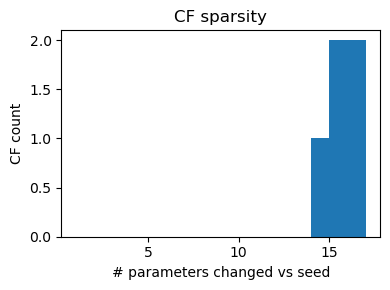

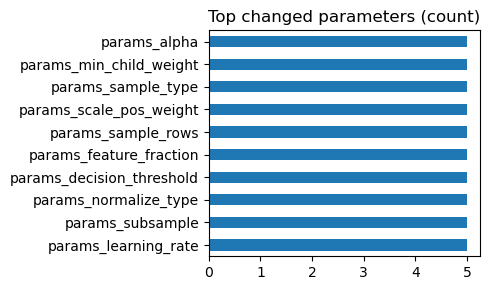

In [19]:
# ───────────────────── CF quick summary & visualization ─────────────────────

if cf_df is None or cf_df.empty:
    print("No counterfactuals found.")
else:
    # 1) Count + preview
    print(f"Counterfactuals found: {len(cf_df)}")
    display(cf_df.head())

    # 2) How many params changed vs seed?
    seed = query_instance.iloc[0]
    cols = cf_df.columns.intersection(query_instance.columns)  # align columns safely
    changed_mask = (cf_df[cols] != seed[cols].values).astype(int)
    changed_per_cf = changed_mask.sum(axis=1)

    plt.figure(figsize=(4,3))
    plt.hist(changed_per_cf, bins=range(1, int(changed_per_cf.max())+2))
    plt.xlabel("# parameters changed vs seed")
    plt.ylabel("CF count")
    plt.title("CF sparsity")
    plt.tight_layout()
    plt.show()

    # 3) Which parameters change most often?
    freq = changed_mask.sum(axis=0).sort_values(ascending=False).head(10)
    if len(freq) > 0:
        freq.plot.barh(figsize=(5,3))
        plt.gca().invert_yaxis()
        plt.title("Top changed parameters (count)")
        plt.tight_layout()
        plt.show()


In [20]:
# ───────────────────── 3. Utility: XGB param mapper ─────────────────────
def _get(r, k, default, cast=float):
    v = r.get(k, np.nan)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return default
    return cast(v)

def cf_to_xgb_params(row):
    r = row.to_dict()
    p = {
        "booster": r.get("params_booster", "gbtree"),
        "n_estimators": _get(r, "params_n_estimators", 500, int),
        "max_depth": _get(r, "params_max_depth", 6, int),
        "learning_rate": _get(r, "params_learning_rate", 0.1, float),
        "min_child_weight": _get(r, "params_min_child_weight", 1.0, float),
        "gamma": _get(r, "params_gamma", 0.0, float),
        "subsample": _get(r, "params_subsample", 1.0, float),
        "colsample_bytree": _get(r, "params_colsample_bytree", 1.0, float),
        "grow_policy": r.get("params_grow_policy", "depthwise"),
        "max_delta_step": _get(r, "params_max_delta_step", 0, int),
        "reg_alpha": _get(r, "params_alpha", 0.0, float),
        "reg_lambda": _get(r, "params_lambda", 1.0, float),
        "tree_method": "gpu_hist", "predictor": "gpu_predictor",
        "objective": "binary:logistic", "eval_metric": "error",
        "verbosity": 0, "random_state": 0,
    }
    if p["booster"] == "dart":
        p.update(
            rate_drop=_get(r, "params_rate_drop", 0.0, float),
            skip_drop=_get(r, "params_skip_drop", 0.0, float),
            sample_type=r.get("params_sample_type", "uniform"),
            normalize_type=r.get("params_normalize_type", "tree"),
        )
    return p


## Evaluating counterfactuals

In [21]:
# ───────────────────── 4. True evaluation (F1, threshold-aware) ─────────────────────
from sklearn.metrics import f1_score

def eval_cf_true_f1(cf_rows, Xtr, ytr, Xva, yva, Xte, yte):
    out = []
    for i, row in cf_rows.reset_index(drop=True).iterrows():
        clf = xgb.XGBClassifier(**cf_to_xgb_params(row))
        try:
            clf.fit(Xtr, ytr)
        except xgb.core.XGBoostError as e:
            # GPU→CPU fallback if needed
            if "Must have at least one device" in str(e):
                clf.set_params(tree_method="hist", predictor="auto")
                clf.fit(Xtr, ytr)
            else:
                raise

        thr = float(row.get("params_decision_threshold", 0.5))
        proba_va = clf.predict_proba(Xva)[:, 1]
        proba_te = clf.predict_proba(Xte)[:, 1]
        yhat_va  = (proba_va >= thr).astype(int)
        yhat_te  = (proba_te >= thr).astype(int)

        out.append({"idx": i, "val_f1": f1_score(yva, yhat_va, zero_division=0),
                          "test_f1": f1_score(yte, yhat_te, zero_division=0),
                          "thr_used": thr})
    return pd.DataFrame(out)

# Build surrogate inputs (unchanged)
cf_pred_input = cf_df.reindex(columns=X_sur.columns).fillna({"params_booster": "gbtree"})
cf_pred_input[cat_cols] = cf_pred_input[cat_cols].fillna("NA")
cf_pred_input[num_cols] = cf_pred_input[num_cols].fillna(0.0)

# Surrogate predicts F1 (since y_sur is 'f1')
cf_valid  = cf_df.assign(pred_f1=rf_pipe.predict(cf_pred_input))
true_res  = eval_cf_true_f1(cf_df, X_tr_enc, y_tr, X_va_enc, y_va, X_te_enc, y_te)

compare = (true_res.join(cf_valid[["pred_f1"]].reset_index(drop=True))
                  .rename(columns={"pred_f1": "surrogate_pred_f1"}))
compare["delta_val_f1_minus_pred"]  = (compare["val_f1"]  - compare["surrogate_pred_f1"]).round(4)
compare["delta_test_f1_minus_pred"] = (compare["test_f1"] - compare["surrogate_pred_f1"]).round(4)

compare = compare.sort_values("test_f1", ascending=False).reset_index(drop=True)
display(compare.head(10))


,idx,val_f1,test_f1,thr_used,surrogate_pred_f1,delta_val_f1_minus_pred,delta_test_f1_minus_pred
0,4,0.687923,0.696029,0.547973,0.642741,0.0452,0.0533
1,1,0.677508,0.683538,0.581402,0.642328,0.0352,0.0412
2,0,0.659233,0.672910,0.501371,0.630130,0.0291,0.0428
3,3,0.661127,0.660504,0.563912,0.540039,0.1211,0.1205
4,2,0.000000,0.000000,0.663853,0.242095,-0.2421,-0.2421
